## Feature Selection (L1 to L2)

Building on the move model, we refine features in two steps:

- **L1 (selection)**  
  Finds which **feature groups matter** (e.g. volatility, trade activity, imbalance)  
  sparse but unstable with correlated features  

- **L2 (refinement)**  
  Applied after grouping  
  ranks **features within each group** and stabilises weights  

### Process

1. Fit L1 model on full feature set  
2. Identify top features → map to feature groups  
3. Expand to include all features within those groups  
4. Fit L2 model on expanded set
5. Repeat for all groups

### Goal

- L1 identify **relevant signal types**  
- L2 select **robust features within each signal**

In [1]:
import pandas as pd
import numpy as np
from binance.client import Client
import time
import black
from pympler import asizeof
import math
import matplotlib.pyplot as plt
import glob

In [2]:
target = "mid_price_moves"

In [3]:
files_final = glob.glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\ml_ready_data\\ml_ready.parquet")

final_dataset = pd.concat([pd.read_parquet(f) for f in files_final])

In [4]:
final_dataset = final_dataset.sort_values("timestamp").reset_index(drop=True)

final_dataset = final_dataset.dropna().reset_index(drop=True)

final_dataset[target].value_counts()

mid_price_moves
0    25213
1    18786
Name: count, dtype: int64

## Key Feature Families (from L1)

From the L1 model, the main drivers of **price movement (activity)** are:

- **Volatility**  
- **Trade intensity**  
- **Total volume / liquidity**  
- **Order book shape**  
- **Trade size distribution**  
- **Order book imbalance**  
- **Trade flow imbalance**  

These capture the core microstructure signals behind market activity.

In [5]:
feature_groups ={
    "volatility": [
        "realized_vol_20_log1p",
        "vol_20_log1p",
        "realized_vol_5_log1p",
        "vol_5_log1p",
    ],
    "trade_intensity":[
        "trade_count_log1p",
        "trade_count_change",
        "buy_count_log1p",
        "sell_count_log1p",
        "total_trade_volume_log1p",
    ],
    "trade_size": [
        "buy_volume_log1p",
        "sell_volume_log1p",
        "avg_trade_size_log1p",
        "max_trade_size_log1p",
        "min_trade_size_log1p",
        "std_trade_size_log1p",
        "max_over_average_log1p",
    ],
    "liquidity": [
        "total_ask_volume_10_log1p",
        "total_bid_volume_10_log1p",
        "total_book_volume_log1p",
        "liquidity_log1p",
        "lob_bids_volume_1_log1p",
        "lob_bids_volume_2_log1p",
        "lob_bids_volume_3_log1p",
        "lob_bids_volume_4_log1p",
        "lob_bids_volume_5_log1p",
        "lob_bids_volume_6_log1p",
        "lob_bids_volume_7_log1p",
        "lob_bids_volume_8_log1p",
        "lob_bids_volume_9_log1p",
        "lob_bids_volume_10_log1p",
    ],

    "volume_pressure": [
        "max_bid_ask_vol_ratio_log1p",
    ],

    "spread": [
        "spread_log1p",
        "rel_spread_log1p",
    ],

    "imbalance": [
        "imbalance_1",
        "imbalance_5",
        "imbalance_10",
        "imbalance_depth_1",
        "imbalance_depth_2",
        "imbalance_depth_3",
        "imbalance_depth_4",
        "imbalance_depth_5",
        "imbalance_depth_6",
        "imbalance_depth_7",
        "imbalance_depth_8",
        "imbalance_depth_9",
        "imbalance_depth_10",
    ],

    "depth_shape": [
        "lob_depth_ratio_2",
        "lob_depth_ratio_3",
        "lob_depth_ratio_4",
        "lob_depth_ratio_5",
        "lob_depth_ratio_6",
        "lob_depth_ratio_7",
        "lob_depth_ratio_8",
        "lob_depth_ratio_9",
        "lob_depth_ratio_10",
    ],

    "trade_flow": [
        "trade_volume_imbalance",
        "trade_volume_change",
        "sell_volume_log1p",
        "buy_volume_log1p"
    ],
}

### L2 Training (within feature groups)

Train L2 models on each feature group to identify the strongest variables within each signal.

In [6]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [7]:
tscv = TimeSeriesSplit(n_splits=10, gap=50)

In [8]:
group = "trade_flow"
X = final_dataset[feature_groups[group]]
y = final_dataset[target]

In [9]:
model = LogisticRegression(
    l1_ratio=0,
    solver="lbfgs",
    C=1.0,
    max_iter=5000,
)

In [10]:
from joblib import Parallel, delayed

def run_move_fold(train_idx, test_idx, X_move, y_move, model):


    oof = np.full(len(X_move), np.nan)

    X_train = X_move.iloc[train_idx].copy()
    X_test  = X_move.iloc[test_idx].copy()

    y_train = y_move.iloc[train_idx]
    y_test  = y_move.iloc[test_idx]

    lower = X_train.quantile(0.01)
    upper = X_train.quantile(0.99)

    X_train = X_train.clip(lower, upper, axis=1)
    X_test  = X_test.clip(lower, upper, axis=1)


    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]

    oof[test_idx] = p

    auc = roc_auc_score(y_test, p)

    coef = model.coef_[0]

    return oof, auc, coef

In [11]:
def run_move_model_parallel(X_move, y_move, model_class, tscv, n_jobs=4):

    results = Parallel(n_jobs=n_jobs)(
        delayed(run_move_fold)(train_idx, test_idx, X_move, y_move, model_class)
        for train_idx, test_idx in tscv.split(X_move)
    )

    oof_preds, fold_aucs, fold_coefs = zip(*results)

    return list(oof_preds), list(fold_aucs), list(fold_coefs)

In [12]:
oof_preds, fold_aucs, fold_coefs = run_move_model_parallel(X,y,model,tscv, n_jobs=8)

[0.6498045372519367, 0.5235142695554917, 0.506183357768952, 0.5020386097587495, 0.4946446626480165, 0.5338252317999402, 0.5090971095659234, 0.5513656445214391, 0.5750238122766739, 0.6837503600076187]


C:\Users\jayod\AppData\Local\Temp\ipykernel_9588\2869559075.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'AUC per Fold')

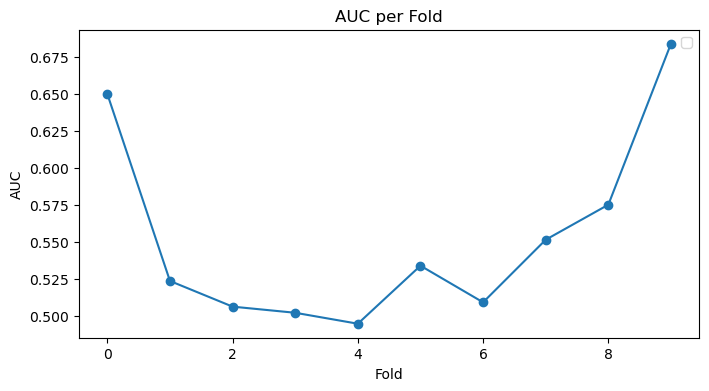

In [13]:
print(fold_aucs)
plt.figure(figsize=(8,4))

plt.plot(fold_aucs, marker="o")

plt.xlabel("Fold")
plt.ylabel("AUC")
plt.legend()
plt.title("AUC per Fold")

In [14]:
final_preds = np.nansum(oof_preds, axis=0)
y_true = y.values

Text(0.5, 1.0, 'Rolling Calibration (window=500)')

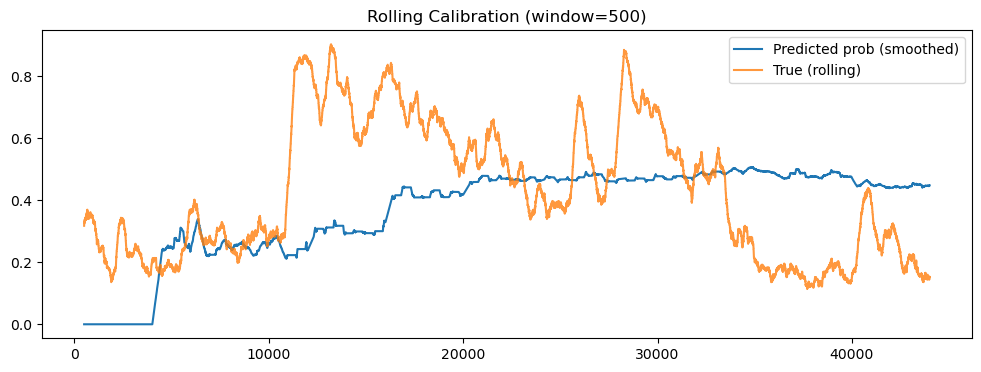

In [15]:
import matplotlib.pyplot as plt

window = 500

pred_smooth = pd.Series(final_preds).rolling(window).mean()
target_smooth = pd.Series(y_true).rolling(window).mean()

plt.figure(figsize=(12,4))
plt.plot(pred_smooth, label="Predicted prob (smoothed)")
plt.plot(target_smooth, label="True (rolling)", alpha=0.8)
plt.legend()
plt.title(f"Rolling Calibration (window={window})")

Text(0.5, 1.0, 'Prediction distribution')

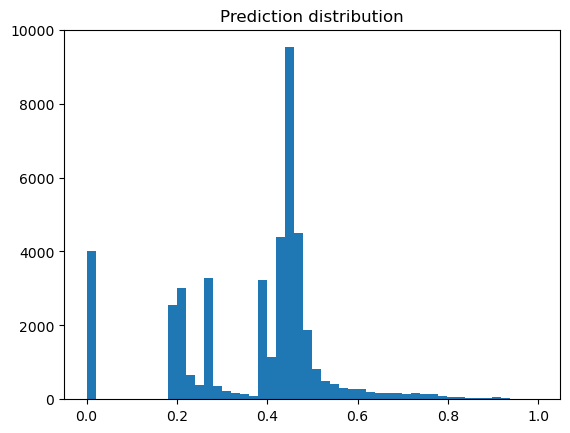

In [16]:
plt.hist(final_preds, bins=50)
plt.title("Prediction distribution")

In [17]:
import pandas as pd

avg_coefs = pd.Series(np.mean(np.abs(fold_coefs), axis=0), index=feature_groups[group])
avg_coefs = avg_coefs.sort_values(key=abs, ascending=False)
pd.set_option("display.max_rows", None)
print(avg_coefs)

sell_volume_log1p         0.254998
buy_volume_log1p          0.252949
trade_volume_change       0.037236
trade_volume_imbalance    0.030433
dtype: float64


In [18]:
sorted_tables = []

for i in range(len(fold_coefs)):
    s = pd.Series(fold_coefs[i], index=feature_groups[group])
    s = s.sort_values(key=abs, ascending=False)

    df_fold = pd.DataFrame({
        f"Fold_{i}_feature": s.index,
        f"Fold_{i}_coef": s.values
    })

    sorted_tables.append(df_fold.reset_index(drop=True))

In [19]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)


coef_table = pd.concat(sorted_tables, axis=1)

print(coef_table)

           Fold_0_feature  Fold_0_coef          Fold_1_feature  Fold_1_coef          Fold_2_feature  Fold_2_coef          Fold_3_feature  Fold_3_coef          Fold_4_feature  Fold_4_coef          Fold_5_feature  Fold_5_coef          Fold_6_feature  Fold_6_coef          Fold_7_feature  Fold_7_coef          Fold_8_feature  Fold_8_coef          Fold_9_feature  Fold_9_coef
0       sell_volume_log1p     0.590475        buy_volume_log1p     0.465734        buy_volume_log1p     0.350181        buy_volume_log1p     0.244494        buy_volume_log1p     0.215776        buy_volume_log1p     0.191308        buy_volume_log1p     0.173690        buy_volume_log1p     0.156208       sell_volume_log1p     0.153241       sell_volume_log1p     0.147223
1        buy_volume_log1p     0.457305       sell_volume_log1p     0.418975       sell_volume_log1p     0.327465       sell_volume_log1p     0.232418       sell_volume_log1p     0.194795       sell_volume_log1p     0.167349       sell_volume_log1p     0.16

In [20]:
from prettytable import PrettyTable

table = PrettyTable()
table.field_names = ["feature", "avg_coef"]

for feature, coef in avg_coefs.round(4).items():
    table.add_row([feature, coef])

with open(f"C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\notebooks\\saved_info\\l2_feature_select\\avg_{group}.txt", "w") as f:
    f.write(str(table))

In [21]:
features = [
    # Vol
    "realized_vol_20_log1p",
    "realized_vol_5_log1p",

    # trade intensity
    "trade_count_log1p",
    "trade_count_change",

    # trade size
    "std_trade_size_log1p",
    "max_trade_size_log1p",
    "avg_trade_size_log1p",

    # liquidity
    "total_bid_volume_10_log1p",
    "total_book_volume_log1p",

    # volume_pressure
    "max_bid_ask_vol_ratio_log1p",

    # spread
    "rel_spread_log1p",

    # imbalance
    "imbalance_5",
    "imbalance_10",
    "imbalance_depth_3",

    # depth shape
    "lob_depth_ratio_4",
    "lob_depth_ratio_2",

    # trade_flow
    "sell_volume_log1p",
]

## Selected Features (L2)

#### Volatility
- realized_vol_20_log1p  
- realized_vol_5_log1p  

#### Trade Intensity
- trade_count_log1p  
- trade_count_change  

#### Trade Size
- std_trade_size_log1p  
- max_trade_size_log1p  
- avg_trade_size_log1p  

#### Liquidity
- total_bid_volume_10_log1p  
- total_book_volume_log1p  

#### Volume Pressure
- max_bid_ask_vol_ratio_log1p  

#### Spread
- rel_spread_log1p  

#### Imbalance
- imbalance_5  
- imbalance_10  
- imbalance_depth_3  

#### Depth Shape
- lob_depth_ratio_4  
- lob_depth_ratio_2  

#### Trade Flow
- sell_volume_log1p  